In [214]:
import pandas as pd
import statsmodels.formula.api as smf
import json
import pyfixest as pf

In [215]:
path_financial = "data/sentences_with_context.json"
path_investment_no_stmt = "results/investment_alpha0_layer12_nostmt.json"
path_investment = "results/investment_alpha0_layer12.json"

In [216]:
with open(path_financial, "r") as f:
    data_financial = json.load(f)

with open(path_investment_no_stmt, "r") as f:
    data_investment_no_stmt = json.load(f)

with open(path_investment, "r") as f:
    data_investment = json.load(f)

In [217]:
df = pd.DataFrame(data_financial)
df_inv_no_stmt = pd.DataFrame(data_investment_no_stmt['results'])
df_inv_stmt = pd.DataFrame(data_investment['results'])
df['sentence_idx'] = df.index

In [218]:
len(df)

40

In [219]:
len(df_inv_no_stmt)

40

In [220]:
len(df_inv_stmt)

40

In [221]:
financial_stuff = ['sector', 'return_3m', 'vol_30d', 'beta', 'market_cap_b']

In [222]:
for cname in financial_stuff:
    df[f'{cname}'] = df['financial_context'].apply(lambda x: x[f'{cname}'])

In [223]:
df_inv_no_stmt = df_inv_no_stmt[['ticker','runs']].reset_index().rename(columns={'index': 'sentence_idx'})

In [224]:
final_df_results_no_investment = pd.DataFrame()

for index, row in df_inv_no_stmt.iterrows():
    runs_df = pd.DataFrame(row['runs'])
    runs_df['ticker'] = row['ticker']
    runs_df['sentence_idx'] = row['sentence_idx']
    final_df_results_no_investment = pd.concat([final_df_results_no_investment, runs_df], ignore_index=True)

In [225]:
df_inv_stmt = df_inv_stmt[['ticker','runs']].reset_index().rename(columns={'index': 'sentence_idx'})

final_df_results_investment = pd.DataFrame()

for index, row in df_inv_stmt.iterrows():
    runs_df = pd.DataFrame(row['runs'])
    runs_df['ticker'] = row['ticker']
    runs_df['sentence_idx'] = row['sentence_idx']
    final_df_results_investment = pd.concat([final_df_results_investment, runs_df], ignore_index=True)

In [226]:
final_df_results_investment['stock_allocation_pct_stm'] = final_df_results_investment['stock']*100/1000

In [227]:
final_df_results_no_investment['stock_allocation_pct_no_stm'] = final_df_results_no_investment['stock']*100/1000

In [228]:
final_df_results_no_investment

,run_idx,response,parsed,treasuries,stock,parse_ok,ticker,sentence_idx,stock_allocation_pct_no_stm
0,0,Given Apple Inc.'s high volatility and negativ...,"{'stock': 0, 'treasuries': 1000}",1000.0,0.0,True,AAPL,0,0.0
1,1,Considering the high volatility and negative 3...,"{'stock': 0, 'treasuries': 1000}",1000.0,0.0,True,AAPL,0,0.0
2,2,Given Apple's high 30-day volatility and negat...,"{'stock': 0, 'treasuries': 1000}",1000.0,0.0,True,AAPL,0,0.0
3,3,Given the high volatility and beta of Apple In...,"{'stock': 200, 'treasuries': 800}",800.0,200.0,True,AAPL,0,20.0
4,4,Considering Apple Inc.'s high 30-day volatilit...,"{'stock': 0, 'treasuries': 1000}",1000.0,0.0,True,AAPL,0,0.0
...,...,...,...,...,...,...,...,...,...
395,5,Given the relatively low volatility and beta o...,"{'stock': 600, 'treasuries': 400}",400.0,600.0,True,SBUX,39,60.0
396,6,"Given the relatively low beta of 0.94, which i...","{'stock': 750, 'treasuries': 250}",250.0,750.0,True,SBUX,39,75.0
397,7,Given the relatively high volatility and beta ...,"{'stock': 250, 'treasuries': 750}",750.0,250.0,True,SBUX,39,25.0
398,8,"Considering the relatively low beta of 0.94, w...","{'stock': 500, 'treasuries': 500}",500.0,500.0,True,SBUX,39,50.0


In [229]:
df = df[['ticker','company','sector','uncertainty','return_3m','vol_30d','beta','market_cap_b','sentence_idx']]

In [230]:
df_final = pd.merge(df, final_df_results_no_investment[['ticker','sentence_idx','stock_allocation_pct_no_stm','run_idx']], on=['ticker','sentence_idx'])

In [231]:
df_final = pd.merge(df_final, final_df_results_investment[['ticker','sentence_idx','stock_allocation_pct_stm','run_idx']], on=['ticker','sentence_idx','run_idx'])

In [232]:
df_long = pd.melt(
    df_final,
    id_vars=['ticker', 'company', 'sector', 'uncertainty',
             'return_3m', 'vol_30d', 'beta', 'market_cap_b', 'run_idx'],
    value_vars=['stock_allocation_pct_no_stm', 'stock_allocation_pct_stm'],
    var_name='condition',
    value_name='stock_alloc'
)

In [233]:
# ── 2. Create treatment indicators ──────────────────────────────────────────
df_long['stm']      = (df_long['condition'] == 'stock_allocation_pct_stm').astype(int)
df_long['high_unc'] = (df_long['uncertainty'] == 'high').astype(int)
df_long['stm_x_unc'] = df_long['stm'] * df_long['high_unc']

In [234]:
df_long = df_long.reset_index(drop=True)

In [235]:
cols = ['stock_alloc', 'stm', 'high_unc', 'stm_x_unc', 
        'vol_30d', 'beta', 'return_3m', 'market_cap_b', 'ticker','sector']

df_clean = df_long[cols].dropna().reset_index(drop=True)

In [236]:
df_clean_no_stm = df_clean[df_clean['stm']==0]

In [237]:
res_fe = pf.feols(
    'stock_alloc ~ vol_30d + beta + return_3m + market_cap_b',
    data=df_clean_no_stm,
    vcov='HC1'
)

pf.summary(res_fe)

###

Estimation:  OLS
Dep. var.: stock_alloc
sample: None = all
Inference:  HC1
Observations:  390

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| Intercept     |     48.688 |        3.456 |    14.086 |      0.000 |  41.892 |  55.484 |
| vol_30d       |     -0.249 |        0.057 |    -4.341 |      0.000 |  -0.362 |  -0.136 |
| beta          |     -7.107 |        3.148 |    -2.258 |      0.025 | -13.296 |  -0.918 |
| return_3m     |      0.330 |        0.073 |     4.525 |      0.000 |   0.187 |   0.474 |
| market_cap_b  |     -0.003 |        0.001 |    -2.149 |      0.032 |  -0.006 |  -0.000 |
---
RMSE: 27.792 R2: 0.174 


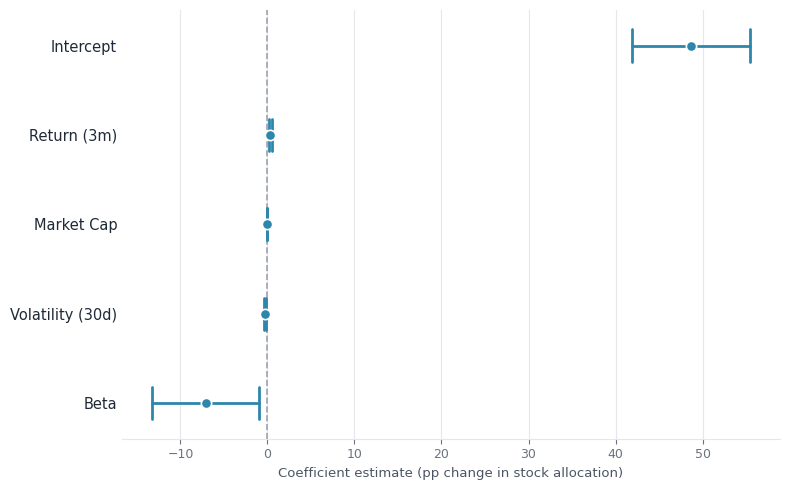

Saved: coeffplot_no_stm.png


In [238]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Pull coefficients directly from the model ─────────────────────────────────
coef_df = pd.DataFrame({
    'label':    ['Intercept','Volatility (30d)', 'Beta', 'Return (3m)', 'Market Cap'],
    'estimate': res_fe.coef().values,
    'se':       res_fe.se().values,
}).assign(
    ci95_low  = lambda d: d['estimate'] - 1.96 * d['se'],
    ci95_high = lambda d: d['estimate'] + 1.96 * d['se'],
).sort_values('estimate').reset_index(drop=True)

TEAL = '#2E86AB'
CAP  = 0.18

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Subtle grid
ax.xaxis.grid(True, color='#E5E7EB', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Zero reference line
ax.axvline(0, color='#9CA3AF', linewidth=1.2, linestyle='--', zorder=1)

for i, row in coef_df.iterrows():
    # Horizontal CI line
    ax.plot([row['ci95_low'], row['ci95_high']], [i, i],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Left cap |
    ax.plot([row['ci95_low'], row['ci95_low']], [i - CAP, i + CAP],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Right cap |
    ax.plot([row['ci95_high'], row['ci95_high']], [i - CAP, i + CAP],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Point
    ax.scatter(row['estimate'], i,
               color=TEAL, s=55, zorder=4,
               edgecolors='white', linewidths=1.2)

# Labels
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['label'], fontsize=10.5, color='#1F2937')
ax.set_xlabel('Coefficient estimate (pp change in stock allocation)', fontsize=9.5, color='#4B5563')
ax.tick_params(axis='x', colors='#6B7280', labelsize=9)
ax.tick_params(axis='y', length=0)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#E5E7EB')

# # Title
# ax.set_title('OLS Coefficient Plot\nSector FE  |  HC1 robust SEs  |  N = 900',
#              fontsize=11, fontweight='bold', color='#111827',
#              loc='left', pad=12)

plt.tight_layout()
plt.savefig('results/coeffplot_no_stm.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: coeffplot_no_stm.png")

In [239]:
res_fe = pf.feols(
    'stock_alloc ~ stm + high_unc + stm_x_unc + vol_30d + beta + return_3m + market_cap_b',
    data=df_clean,
    vcov='HC1'
)

pf.summary(res_fe)

###

Estimation:  OLS
Dep. var.: stock_alloc
sample: None = all
Inference:  HC1
Observations:  780

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| Intercept     |     48.737 |        3.673 |    13.268 |      0.000 |  41.526 |  55.948 |
| stm           |      8.500 |        4.815 |     1.765 |      0.078 |  -0.951 |  17.951 |
| high_unc      |     -4.677 |        3.591 |    -1.302 |      0.193 | -11.728 |   2.373 |
| stm_x_unc     |    -13.968 |        5.339 |    -2.616 |      0.009 | -24.448 |  -3.487 |
| vol_30d       |     -0.182 |        0.040 |    -4.497 |      0.000 |  -0.262 |  -0.103 |
| beta          |     -6.010 |        2.225 |    -2.701 |      0.007 | -10.379 |  -1.642 |
| return_3m     |      0.269 |        0.053 |     5.051 |      0.000 |   0.164 |   0.373 |
| market_cap_b  |     -0.001 |        0.001 |    -0.955 |      0.340 |  -0.004 | 

In [244]:
res_fe = pf.feols(
    'stock_alloc ~ stm + high_unc + stm_x_unc + vol_30d + beta + return_3m + market_cap_b | sector',
    data=df_clean,
    vcov='HC1'
)

pf.summary(res_fe)

###

Estimation:  OLS
Dep. var.: stock_alloc, Fixed effects: sector
sample: None = all
Inference:  HC1
Observations:  780

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| stm           |      8.500 |        4.891 |     1.738 |      0.083 |  -1.102 |  18.102 |
| high_unc      |     -4.207 |        4.236 |    -0.993 |      0.321 | -12.523 |   4.108 |
| stm_x_unc     |    -13.968 |        5.395 |    -2.589 |      0.010 | -24.559 |  -3.376 |
| vol_30d       |     -0.185 |        0.045 |    -4.144 |      0.000 |  -0.273 |  -0.097 |
| beta          |     -5.688 |        2.492 |    -2.283 |      0.023 | -10.579 |  -0.796 |
| return_3m     |      0.333 |        0.078 |     4.270 |      0.000 |   0.180 |   0.486 |
| market_cap_b  |      0.001 |        0.002 |     0.251 |      0.802 |  -0.004 |   0.005 |
---
RMSE: 28.487 R2: 0.147 R2 Within: 0.091 


In [245]:
# res_fe = pf.feols(
#     'stock_alloc ~ stm + high_unc + stm_x_unc + vol_30d + beta + return_3m + market_cap_b | sector',
#     data=df_clean,
#     vcov={'CRV1': 'ticker'}
# )

# pf.summary(res_fe)

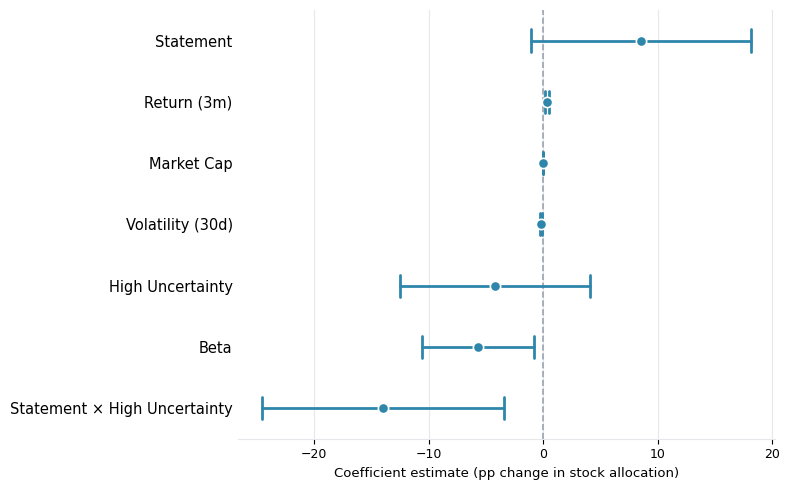

Saved: coeffplot.png


In [246]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Pull coefficients directly from the model ─────────────────────────────────
coef_df = pd.DataFrame({
    'label':    ['Statement', 'High Uncertainty', 'Statement × High Uncertainty',
                 'Volatility (30d)', 'Beta', 'Return (3m)', 'Market Cap'],
    'estimate': res_fe.coef().values,
    'se':       res_fe.se().values,
}).assign(
    ci95_low  = lambda d: d['estimate'] - 1.96 * d['se'],
    ci95_high = lambda d: d['estimate'] + 1.96 * d['se'],
).sort_values('estimate').reset_index(drop=True)

TEAL = '#2E86AB'
CAP  = 0.18

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Subtle grid
ax.xaxis.grid(True, color='#E5E7EB', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Zero reference line
ax.axvline(0, color='#9CA3AF', linewidth=1.2, linestyle='--', zorder=1)

for i, row in coef_df.iterrows():
    # Horizontal CI line
    ax.plot([row['ci95_low'], row['ci95_high']], [i, i],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Left cap |
    ax.plot([row['ci95_low'], row['ci95_low']], [i - CAP, i + CAP],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Right cap |
    ax.plot([row['ci95_high'], row['ci95_high']], [i - CAP, i + CAP],
            color=TEAL, linewidth=2, zorder=2, solid_capstyle='round')
    # Point
    ax.scatter(row['estimate'], i,
               color=TEAL, s=55, zorder=4,
               edgecolors='white', linewidths=1.2)

# Labels
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df['label'], fontsize=10.5, color="#000000")
ax.set_xlabel('Coefficient estimate (pp change in stock allocation)', fontsize=9.5, color="#000000")
ax.tick_params(axis='x', colors="#000000", labelsize=9)
ax.tick_params(axis='y', length=0)

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#E5E7EB')

# # Title
# ax.set_title('OLS Coefficient Plot\nSector FE  |  HC1 robust SEs  |  N = 900',
#              fontsize=11, fontweight='bold', color='#111827',
#              loc='left', pad=12)

plt.tight_layout()
plt.savefig('results/coeffplot.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: coeffplot.png")